#### 1. Imports / settings
- It prints the repo root path (Prints the repo root path (e.g.../Automation/ode-workflow)
- No import errors

In [1]:
import sys
from pathlib import Path

# Add repo root (the folder that contains configs/, scripts/, models/, notebooks/)
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))

print(repo_root)

import json
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from scripts.run_sweep import run_reference, load_config


C:\Users\LevinSchöpfer\Automation\ode-workflow


C:\Temp\miniforge3\envs\ode-sim\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


#### 2. Run the reference case
- Confirms pipeline works end-to-end
- Prints dictionary with results
- Compare to BM output

In [2]:
config_path = repo_root / "configs" / "Walz_sweep.yaml"
summary = run_reference(config_path=config_path, dose_mgkg=1.0, interval_weeks=2)
summary



{'C_trough_ugml': 2.060862390869303,
 'C_avg_ugml': 5.070355666937764,
 't_end_days': 350.0,
 'dose_mgkg': 1.0,
 'interval_weeks': 2,
 'TARC_red_trough': 0.20326937300174563}

#### 3. Loads results from results repo (.json)
- Summary exists: True
- H5 exists: True
- Prints dictionary with results

In [3]:
cfg = load_config(config_path)
run_dir = Path(cfg["output"]["root_dir"]) / "1.0mgkg_q2w"

summary_path = run_dir / "run_summary.json"
h5_path = run_dir / "run.h5"

print("Run dir:", run_dir)
print("Summary exists:", summary_path.exists())
print("H5 exists:", h5_path.exists())

with open(summary_path, "r") as f:
    summary_json = json.load(f)

summary_json


Run dir: results\Walz_sweep\1.0mgkg_q2w
Summary exists: False
H5 exists: False


FileNotFoundError: [Errno 2] No such file or directory: 'results\\Walz_sweep\\1.0mgkg_q2w\\run_summary.json'

#### 4. Read time series from HDF5
- Prints t_days (for q2W)
    - starts at 336
    - ends at 350

In [14]:
with h5py.File(h5_path, "r") as f:
    t_days = f["t_days"][:]
    Central = f["derived/Central_ugml"][:]
    RO3 = f["derived/RO3"][:]

t_days[:5], t_days[-5:]


(array([336. , 336.1, 336.2, 336.3, 336.4]),
 array([349.6, 349.7, 349.8, 349.9, 350. ]))

#### 5. Plot last-interval timecourses
- Prints strictly smooth decay curve
- Prints smooth spike between y-values of 0.0 - 1.0 

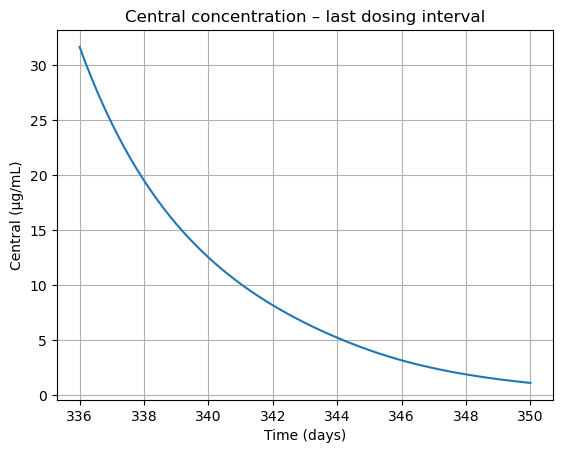

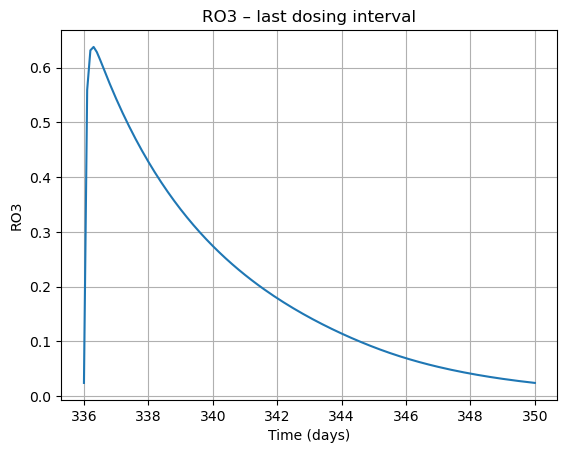

In [15]:
plt.figure()
plt.plot(t_days, Central)
plt.xlabel("Time (days)")
plt.ylabel("Central (µg/mL)")
plt.title("Central concentration – last dosing interval")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t_days, RO3)
plt.xlabel("Time (days)")
plt.ylabel("RO3")
plt.title("RO3 – last dosing interval")
plt.grid(True)
plt.show()


#### 6. Recompute summary metrics from arrays (.h5)
- Prints Dictionary with results
- Values should match those from Step 2 & 3

In [16]:
interval_weeks = 2
Iota_days = interval_weeks * 7

C_trough = float(Central[-1])
RO3_trough = float(RO3[-1])
C_avg = float(np.trapz(Central, t_days) / Iota_days)

recalc = {
    "C_trough_ugml": C_trough,
    "C_avg_ugml": C_avg,
    "RO3_trough": RO3_trough,
}
recalc


{'C_trough_ugml': 1.1002784558117593,
 'C_avg_ugml': 9.364332501645393,
 'RO3_trough': 0.02416738225920227}

#### 7. Compare recomputed from .h5 (Step 6) vs saved summary in .json (Step 3)
- diff ~ 0.0

In [17]:
compare = pd.DataFrame([
    {"metric": k, "saved": summary_json[k], "recomputed": recalc[k], "diff": recalc[k] - summary_json[k]}
    for k in recalc.keys()
])
compare


,metric,saved,recomputed,diff
0,C_trough_ugml,1.100278,1.100278,0.0
1,C_avg_ugml,9.364333,9.364333,0.0
2,RO3_trough,0.024167,0.024167,0.0


#### 8. Sensitivity: dt_days (output grid only)
- Tries different integration steps (dt)
- C_avg should barely change
- C_trough may change slightly

In [18]:
from scripts.run_sweep import run_one

dose = 1.0
interval = 2

dt_values = [0.2, 0.1, 0.05, 0.02]
rows = []

cfg_base = load_config(config_path)

for dt in dt_values:
    cfg_test = json.loads(json.dumps(cfg_base))  # deep copy
    cfg_test["simulation"]["dt_days"] = dt

    out_dir = Path(cfg_test["output"]["root_dir"]) / f"validation_dt_{dt}"
    s = run_one(cfg_test, dose, interval, out_dir)

    s["dt_days"] = dt
    rows.append(s)

pd.DataFrame(rows).sort_values("dt_days")


,C_trough_ugml,C_avg_ugml,RO3_trough,t_end_days,dose_mgkg,interval_weeks,dt_days
3,1.100278,9.363888,0.024167,350.0,1.0,2,0.02
2,1.100278,9.363985,0.024167,350.0,1.0,2,0.05
1,1.100278,9.364333,0.024167,350.0,1.0,2,0.10
0,1.100278,9.365721,0.024167,350.0,1.0,2,0.20


#### 9. Sensitivity: solver method (Radau vs BDF)
- Tries Radau and BDF as solver
- Checks numerical robustness
- Difference should be small

In [19]:
methods = ["Radau", "BDF"]
rows = []

cfg_base = load_config(config_path)

for method in methods:
    cfg_test = json.loads(json.dumps(cfg_base))
    cfg_test["simulation"]["solver"]["method"] = method

    out_dir = Path(cfg_test["output"]["root_dir"]) / f"validation_solver_{method}"
    s = run_one(cfg_test, 1.0, 2, out_dir)
    s["method"] = method
    rows.append(s)

pd.DataFrame(rows)


,C_trough_ugml,C_avg_ugml,RO3_trough,t_end_days,dose_mgkg,interval_weeks,method
0,1.100278,9.364333,0.024167,350.0,1.0,2,Radau
1,1.100279,9.364333,0.024167,350.0,1.0,2,BDF


#### 10. Sensitivity: tolerances
- Tries different tolerance measures
- Tightening tolerances should change results only slightly

In [20]:
tols = [
    ("1e-6", "1e-9"),
    ("1e-7", "1e-10"),
    ("1e-8", "1e-11"),
]

rows = []
cfg_base = load_config(config_path)

for rtol_str, atol_str in tols:
    cfg_test = json.loads(json.dumps(cfg_base))
    cfg_test["simulation"]["solver"]["rtol"] = float(rtol_str)
    cfg_test["simulation"]["solver"]["atol"] = float(atol_str)

    out_dir = Path(cfg_test["output"]["root_dir"]) / f"validation_tol_r{rtol_str}_a{atol_str}"
    s = run_one(cfg_test, 1.0, 2, out_dir)
    s["rtol"] = rtol_str
    s["atol"] = atol_str
    rows.append(s)

pd.DataFrame(rows)


,C_trough_ugml,C_avg_ugml,RO3_trough,t_end_days,dose_mgkg,interval_weeks,rtol,atol
0,1.100278,9.364333,0.024167,350.0,1.0,2,1e-6,1e-9
1,1.100278,9.364333,0.024167,350.0,1.0,2,1e-7,1e-10
2,1.100278,9.364333,0.024167,350.0,1.0,2,1e-8,1e-11
